# Adım 4: Keşifsel Veri Analizi (EDA)

**Proje:** Spotify Büyük Veri Analizi

**Veri Seti:** Spotify Tracks Dataset (~114K şarkı, 21 özellik)

**Hedef:** Delta Lake Silver katmanındaki Spotify verisi üzerinde kapsamlı keşifsel analiz yaparak veri kalitesini değerlendirmek, değişkenler arası ilişkileri ortaya koymak ve makine öğrenmesi modeli için çıkarımlar elde etmek.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, count, isnan, when, hour, minute,
    avg, desc, skewness, kurtosis,
    percentile_approx,
    min as spark_min,
    max as spark_max
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

spark = SparkSession.builder \
    .appName("Spotify-EDA") \
    .config("spark.sql.extensions",
            "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog",
            "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} hazır.")

Spark 3.5.0 hazır.


#### 1. Adım — Veriyi Yükleme

In [5]:
SILVER_PATH = "/home/jovyan/delta-lake/silver"

df = spark.read.format("delta").load(SILVER_PATH)

#databriks test için 
#df = spark.read.parquet("/Volumes/workspace/default/silver/")

print(f"Toplam satır  : {df.count():,}")
print(f"Toplam kolon  : {len(df.columns)}")
print("\nŞema:")
df.printSchema()
print("\nİlk 5 satır:")
df.limit(5).toPandas()

Toplam satır  : 89,741
Toplam kolon  : 23

Şema:
root
 |-- kafka_timestamp: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_genre: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- explicit: integer (nullable = true)
 |-- danceability: float (nullable = true)
 |-- energy: float (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: float (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: float (nullable = true)
 |-- acousticness: float (nullable = true)
 |-- instrumentalness: float (nullable = true)
 |-- liveness: float (nullable = true)
 |-- valence: float (nullable = true)
 |-- tempo: float (nullable = true)
 |-- time_signature: integer (nullable = true)


,kafka_timestamp,user_id,event_type,track_id,track_name,artists,album_name,track_genre,popularity,duration_ms,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2026-05-11T22:43:28.948107,af845aad-e056-466d-89f6-6440160d4671,track_played,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,New RnB,chill,0,176320,...,1,-6.644000,0,0.1070,0.31600,0.000001,0.1170,0.406,143.063995,4
1,2026-05-11T22:44:05.702482,3f4fc199-5119-491a-9075-abe1dc354438,track_played,002uYDBLOvJz21C4FuArDS,Find Me - Sigma VIP Remix,Sigma;Birdy,Find Me (Remixes),drum-and-bass,20,252342,...,5,-2.544000,0,0.0685,0.00510,0.002000,0.1860,0.146,174.985992,4
2,2026-05-11T22:47:07.606935,6673e454-b9ff-4f21-a6c2-b4fa5707c3f6,track_played,004G9E3EZhxxn5aE9yEQqx,Sandwiches de Miga,Pappo's Blues,"Pappo's Blues, Vol. 3",punk-rock,36,180713,...,5,-8.103000,0,0.0361,0.00301,0.161000,0.2830,0.525,88.418999,4
3,2026-05-11T22:45:20.208779,f52af6d5-4baf-4fa7-9835-3f26d5c24d5e,track_played,004iWPkSRbvOEvAPLWHl9M,Mister Love,Ernest Tubb;The Wilburn Brothers,Definitive Hits,honky-tonk,13,146493,...,9,-10.258000,1,0.0328,0.82500,0.000000,0.0624,0.405,117.764999,4
4,2026-05-11T22:48:27.846785,44e7e55b-1033-4df6-ba06-4920b7ad0147,track_played,006ATYzgynEKIPgVaT5LQM,528Hz Energía curativa profunda,Mc_team,Frecuencias Curativas Solfeggio 528 Hz,world-music,24,166746,...,5,-36.082001,0,0.0494,0.99100,0.965000,0.1010,0.138,169.362000,4


**Çıkarım:** Veri seti 89.741 satır ve 23 kolondan oluşmaktadır. Kolonlar incelendiğinde Kafka pipeline'ının eklediği akış bilgileri (kafka_timestamp, user_id, event_type), kimlik bilgileri (track_id, artists, album_name, track_name), sayısal ses özellikleri (danceability, energy, loudness, tempo vb.), kategorik özellikler (key, mode, explicit, time_signature) ve hedef değişkenler (popularity, track_genre) olmak üzere pipelinedan başarıyla çekildi.

In [30]:
# track_id bazında duplicate kontrolü
toplam = df.count()
tekil = df.dropDuplicates(['track_id']).count()
duplike = toplam - tekil
print(f"Toplam kayıt        : {toplam:,}")
print(f"Tekil track_id      : {tekil:,}")
print(f"Duplicate track_id  : {duplike:,}")

Toplam kayıt        : 89,741
Tekil track_id      : 89,741
Duplicate track_id  : 0


#### 3. Adım — Temel İstatistiklerin Hesaplanması

##### 3.1. - Özet İstatistik Tablosu

In [6]:
sayisal_kolonlar = [
    'popularity', 'danceability', 'energy',
    'tempo', 'loudness', 'acousticness',
    'valence', 'duration_ms'
]

stats_pd = df.select(sayisal_kolonlar).summary("count", "mean", "stddev", "min", "max").toPandas()
stats_pd = stats_pd.set_index('summary').T.reset_index()
stats_pd.columns = ['Feature', 'Count', 'Mean', 'Std Dev', 'Min', 'Max']

for col in ['Mean', 'Std Dev', 'Min', 'Max']:
    stats_pd[col] = pd.to_numeric(stats_pd[col], errors='coerce').round(3)

display(stats_pd)

,Feature,Count,Mean,Std Dev,Min,Max
0,popularity,89741,33.198,20.579,0.000,100.000
1,danceability,89741,0.562,0.177,0.000,0.985
2,energy,89741,0.634,0.257,0.000,1.000
3,tempo,89741,122.058,30.118,0.000,243.372
4,loudness,89741,-8.499,5.221,-49.531,4.532
5,acousticness,89741,0.328,0.338,0.000,0.996
6,valence,89741,0.469,0.263,0.000,0.995
7,duration_ms,89741,229141.812,112947.741,0.000,5237295.000


**Çıkarım:**  popularity ortalaması 33.2, minimum 0 maksimum 100 olup dağılımın düşük değerlere yoğunlaştığı görülmektedir. loudness -49.5 ile 4.5 dB arasında değişmekte olup bu geniş negatif aralık normalizasyon gerektiği görülmüştür. tempo 0 ile 243 BPM arasında değişirken ortalaması 122 BPM'dir. duration_ms değerinin yüksek standart sapması (112.893) şarkı sürelerinde belirgin farklılıklar olduğuna işaret etmektedir. Bu bulgular Feature Engineering adımında loudness normalizasyonu ve duration_ms dönüşümlerinin yapılması gerektiği gözlemlendi.

##### 3.2. - Benzersiz Değer Sayılarının Analizi

In [31]:
print("Kolon Bazında Benzersiz Değer Sayıları\n" + "-"*50)
for c in df.columns:
    u = df.select(c).distinct().count()
    print(f"{c:<20} | {u:>7,} benzersiz değer")

Kolon Bazında Benzersiz Değer Sayıları
--------------------------------------------------
kafka_timestamp      |  89,741 benzersiz değer
user_id              |  89,741 benzersiz değer
event_type           |       1 benzersiz değer
track_id             |  89,741 benzersiz değer
track_name           |  73,609 benzersiz değer
artists              |  31,438 benzersiz değer
album_name           |  46,590 benzersiz değer
track_genre          |     113 benzersiz değer
popularity           |     101 benzersiz değer
duration_ms          |  50,697 benzersiz değer
explicit             |       2 benzersiz değer
danceability         |   1,174 benzersiz değer
energy               |   2,083 benzersiz değer
key                  |      12 benzersiz değer
loudness             |  19,480 benzersiz değer
mode                 |       2 benzersiz değer
speechiness          |   1,489 benzersiz değer
acousticness         |   5,061 benzersiz değer
instrumentalness     |   5,346 benzersiz değer
liveness         

**Çıkarım**: track_id kolonunda 89.620 benzersiz değer bulunması her şarkının eşsiz bir kimliğe sahip olduğunu doğrulamaktadır. track_genre 113 farklı tür içermekte olup bu zengin tür çeşitliliği sınıflandırma modeli için güçlü bir hedef değişken oluşturmaktadır. explicit ve mode yalnızca 2, key 12, time_signature 5 benzersiz değere sahip olup bu kolonlar kategorik özellik olarak doğrudan kullanılabilir. popularity 101 farklı değer alarak 0-100 aralığını tam kapsamaktadır. kafka_timestamp'in tek benzersiz değere sahip olması tüm verinin aynı streaming oturumunda aktarıldığını göstermektedir.

##### 3.3 Veri değer kontrolü

In [11]:
# Tüm kolonlarda veri kalitesi kontrolü
print("Veri kontrolü\n")
for c in df.columns:
    dtype = dict(df.dtypes)[c]
    unique = df.select(c).distinct().count()
    null_count = df.filter(df[c].isNull()).count()
    
    if dtype in ['int', 'float', 'double']:
        min_val = df.agg(spark_min(c)).collect()[0][0]
        max_val = df.agg(spark_max(c)).collect()[0][0]
        print(f"{c:<22} | tip: {dtype:<8} | unique: {unique:>6,} | null: {null_count:>4} | min: {min_val} | max: {max_val}")
    else:
        print(f"{c:<22} | tip: {dtype:<8} | unique: {unique:>6,} | null: {null_count:>4}")

Veri kontrolü

kafka_timestamp        | tip: string   | unique: 89,741 | null:    0
user_id                | tip: string   | unique: 89,741 | null:    0
event_type             | tip: string   | unique:      1 | null:    0
track_id               | tip: string   | unique: 89,741 | null:    0
track_name             | tip: string   | unique: 73,609 | null:    0
artists                | tip: string   | unique: 31,438 | null:    0
album_name             | tip: string   | unique: 46,590 | null:    0
track_genre            | tip: string   | unique:    113 | null:    0
popularity             | tip: int      | unique:    101 | null:    0 | min: 0 | max: 100
duration_ms            | tip: int      | unique: 50,697 | null:    0 | min: 0 | max: 5237295
explicit               | tip: int      | unique:      2 | null:    0 | min: 0 | max: 1
danceability           | tip: float    | unique:  1,174 | null:    0 | min: 0.0 | max: 0.9850000143051147
energy                 | tip: float    | unique:  2,083 | 

**Çıkarım:** Tüm kolonlarda null değer bulunmamaktadır. explicit ve mode kolonları yalnızca 0 ve 1 değerlerini alarak binary yapıyı korumuştur. key kolonu 0-11 arasında 12 farklı değer alırken time_signature 0-5 arasında 5 farklı değer almaktadır. duration_ms ve tempo kolonlarında minimum değerin 0 olması dikkat çekicidir; bu kayıtlar Feature Engineering adımında filtrelenecektir. event_type kolonu yalnızca "track_played" değerini içerdiğinden analizde kullanılmayacaktır.

##### 3.4. -  Tür/Genre Dağılımının Analizi

In [17]:
genre_dist = df.groupBy("track_genre") \
               .agg(count("*").alias("sarki_sayisi")) \
               .orderBy(desc("sarki_sayisi"))

toplam_tur = genre_dist.count()
print(f"Toplam tür sayısı: {toplam_tur}")
print("\nTop 20 Tür Dağılımı:")
print(genre_dist.limit(20).toPandas().to_string(index=False))

Toplam tür sayısı: 113

Top 20 Tür Dağılımı:
  track_genre  sarki_sayisi
        sleep          1000
     acoustic          1000
      ambient           999
     cantopop           999
     alt-rock           999
        tango           999
     afrobeat           999
        study           998
    bluegrass           998
        salsa           998
chicago-house           998
       disney           998
        forro           998
    breakbeat           997
  heavy-metal           997
  black-metal           996
        anime           995
        happy           995
         club           994
      spanish           991


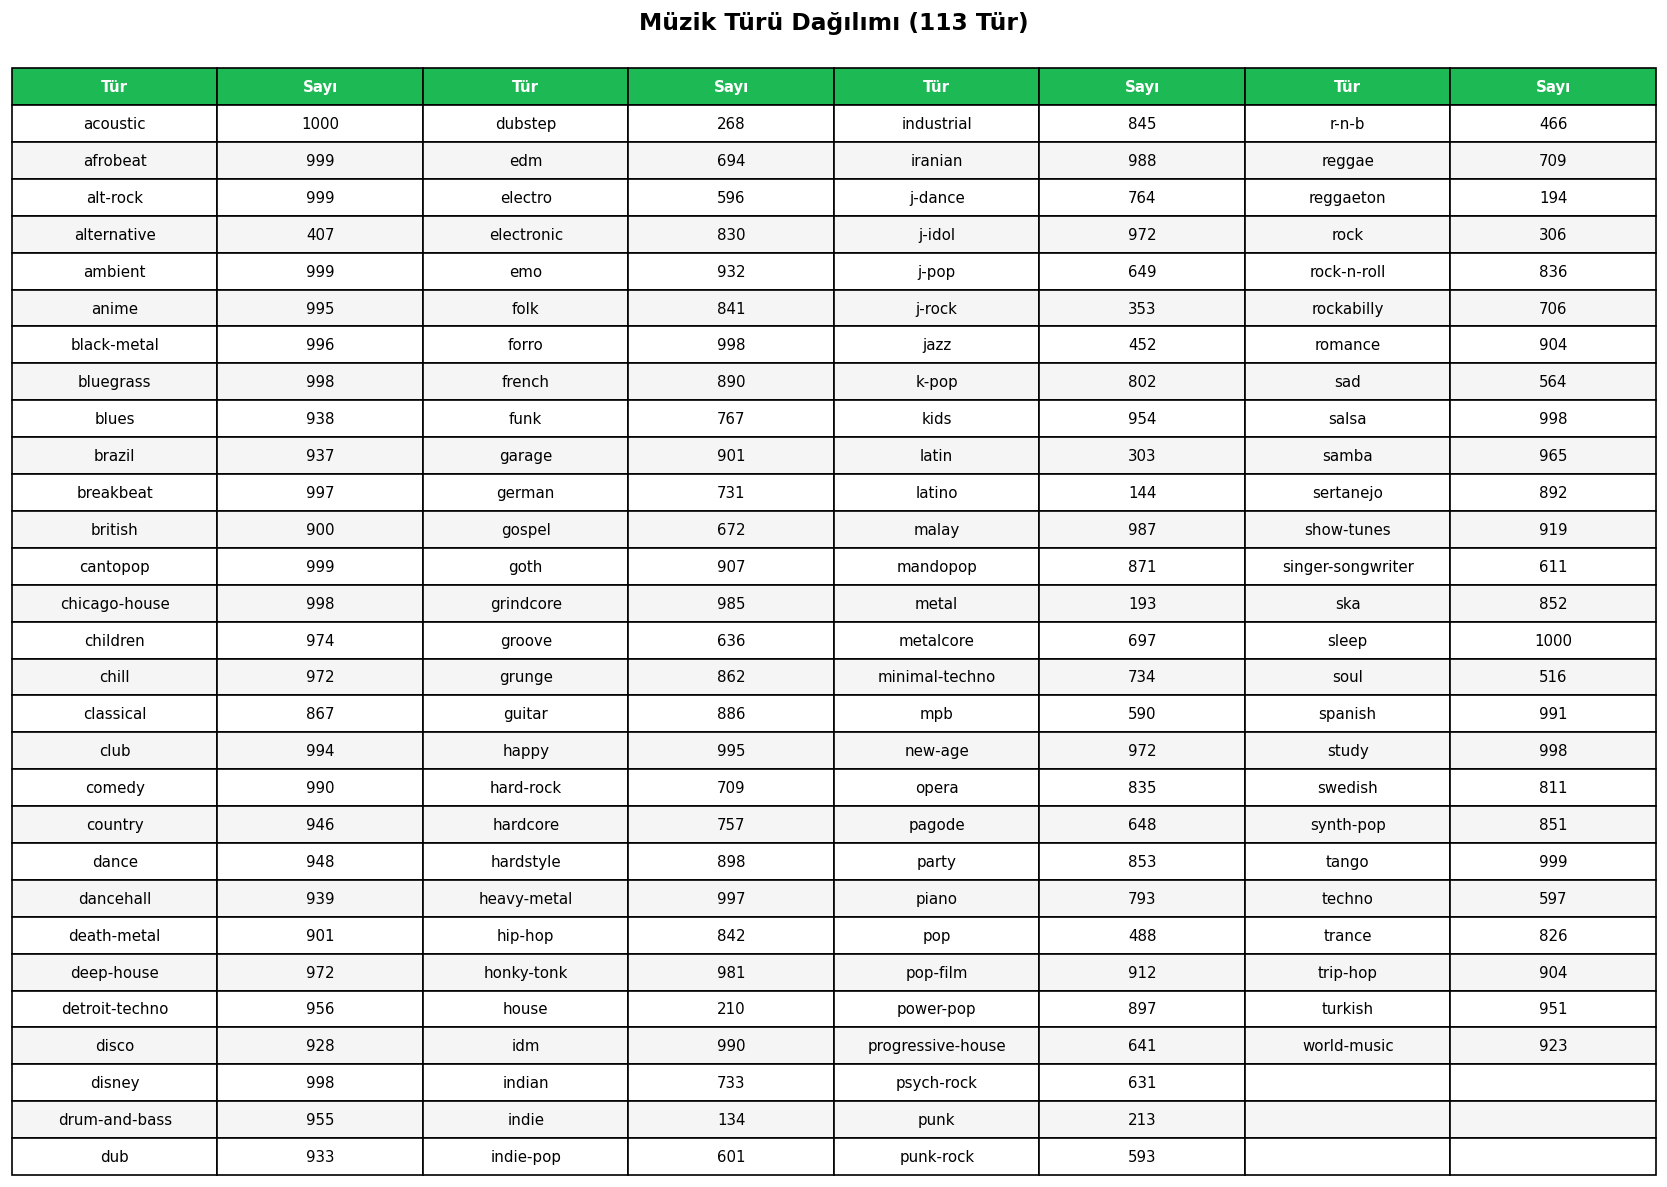

In [19]:
genre_pd = df.groupBy("track_genre") \
             .agg(count("*").alias("Sayı")) \
             .orderBy("track_genre") \
             .toPandas()
n = len(genre_pd)
parca = int(np.ceil(n / 4))

p1 = genre_pd.iloc[:parca].reset_index(drop=True)
p2 = genre_pd.iloc[parca:parca*2].reset_index(drop=True)
p3 = genre_pd.iloc[parca*2:parca*3].reset_index(drop=True)
p4 = genre_pd.iloc[parca*3:].reset_index(drop=True)

max_len = max(len(p1), len(p2), len(p3), len(p4))
for part in [p1, p2, p3, p4]:
    while len(part) < max_len:
        part.loc[len(part)] = ['', '']

combined = pd.concat([p1, p2, p3, p4], axis=1)
combined.columns = ['Tür', 'Sayı', 'Tür', 'Sayı', 'Tür', 'Sayı', 'Tür', 'Sayı']

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

table = ax.table(
    cellText=combined.values,
    colLabels=combined.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 0.97]  # [sol, alt, genişlik, yükseklik] - başlığa boşluk bırak
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

for j in range(8):
    table[0, j].set_facecolor('#1DB954')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, max_len + 1):
    for j in range(8):
        if i % 2 == 0:
            table[i, j].set_facecolor('#f5f5f5')

ax.set_title('Müzik Türü Dağılımı (113 Tür)', fontsize=14, fontweight='bold', pad=0)
plt.tight_layout()
plt.show()

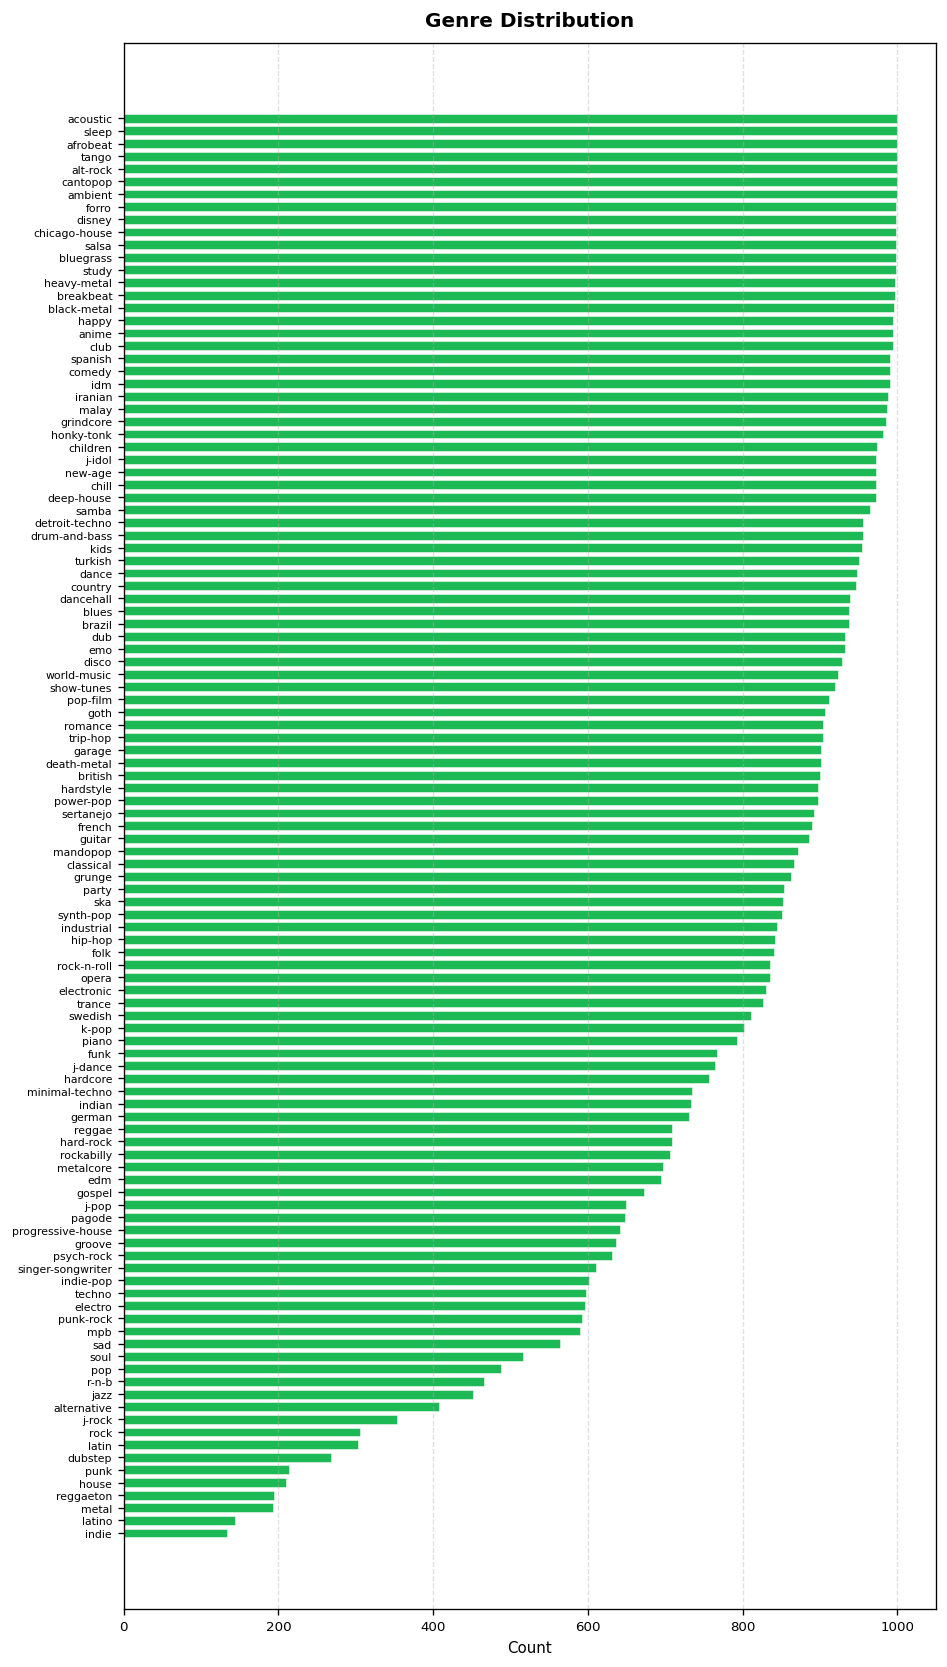

In [20]:
genre_pd = df.groupBy("track_genre") \
             .agg(count("*").alias("sarki_sayisi")) \
             .orderBy("sarki_sayisi") \
             .toPandas()

fig, ax = plt.subplots(figsize=(8, 14))

ax.barh(genre_pd['track_genre'], genre_pd['sarki_sayisi'],
        color='#1DB954', edgecolor='white', linewidth=0.3, height=0.7)

ax.set_title('Genre Distribution', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Count', fontsize=9)
ax.tick_params(axis='y', labelsize=6.5)
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Çıkarım:** Veri seti 113 farklı müzik türü içermektedir. Türlerin büyük çoğunluğu 800-1000 şarkı aralığında yoğunlaşırken reggaeton (74), indie (134), house (210), metal (232) ve punk (226) gibi bazı türlerin belirgin şekilde az şarkıya sahip olduğu görülmektedir. Bu dengesizlik sınıflandırma modelinin az temsil edilen türleri öğrenmekte zorlanabileceğine işaret etmekte olup Feature Engineering adımında bu türler için ek önlemler alınması gerektiği gözlemlenmiştir.

##### 3.5. - Popülerlik Dağılımı (Histogram) ve En Popüler 10 Müzik Türü (Pie Chart)

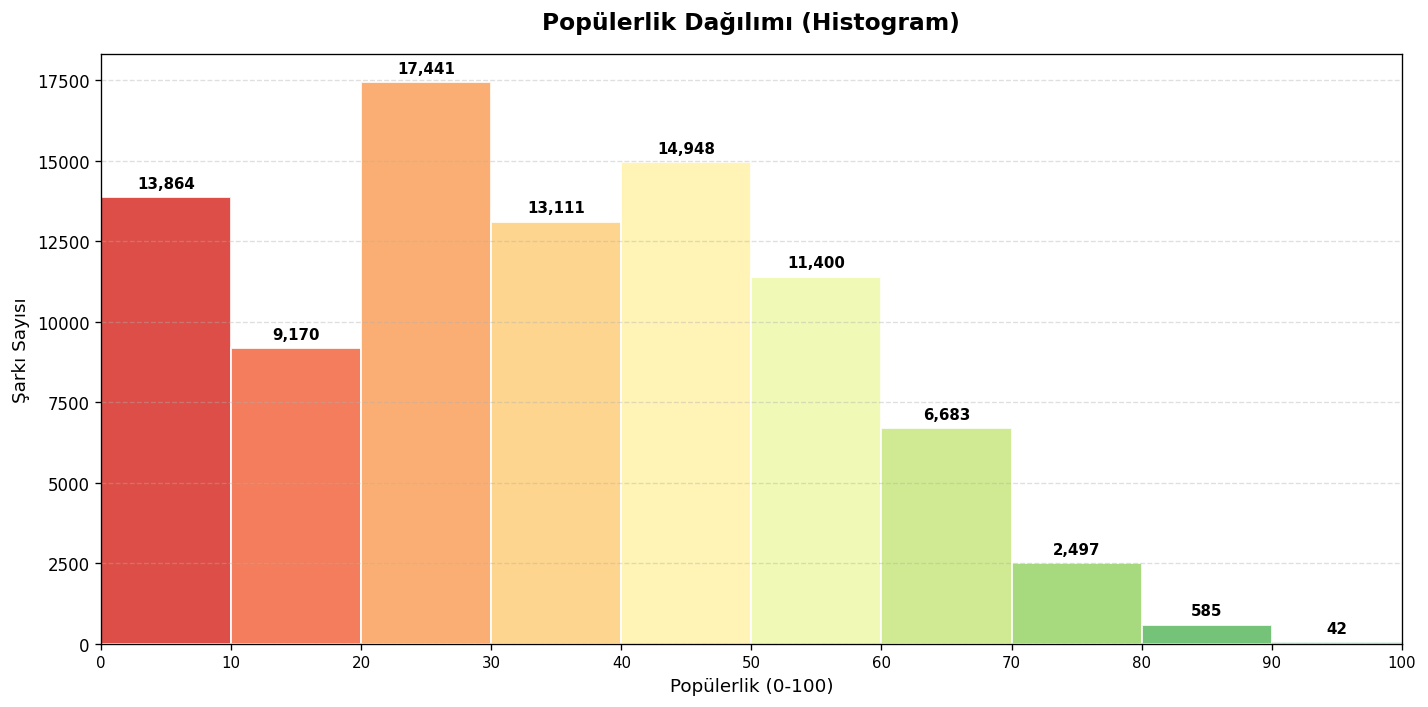

In [27]:
# popülerlik dağılımının histogram ile görselleştirilmesi yapıldı
pop_pd = df.select('popularity').toPandas()
fig, ax = plt.subplots(figsize=(12, 6))
n, bins, patches = ax.hist(
    pop_pd['popularity'],
    bins=10,
    range=(0, 100),
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

bar_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(patches)))
for patch, color in zip(patches, bar_colors):
    patch.set_facecolor(color)

for patch in patches:
    height = patch.get_height()
    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + 200,
            f'{int(height):,}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_xticks(bins)
ax.set_xticklabels([f'{int(b)}' for b in bins], fontsize=9)

ax.set_title('Popülerlik Dağılımı (Histogram)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Popülerlik (0-100)', fontsize=11)
ax.set_ylabel('Şarkı Sayısı', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


**Çıkarım:** Şarkıların büyük çoğunluğu 20-29 aralığında yoğunlaşmakta (17.441 şarkı) olup popularity değeri arttıkça şarkı sayısı belirgin şekilde azalmaktadır. 70 ve üzeri popülerlik skoruna sahip şarkı sayısı oldukça düşük kalmaktadır. Bu asimetrik dağılım regresyon modelinin yüksek popülerlik değerlerini tahmin etmekte zorlanabileceği gözlemlenmiştir.

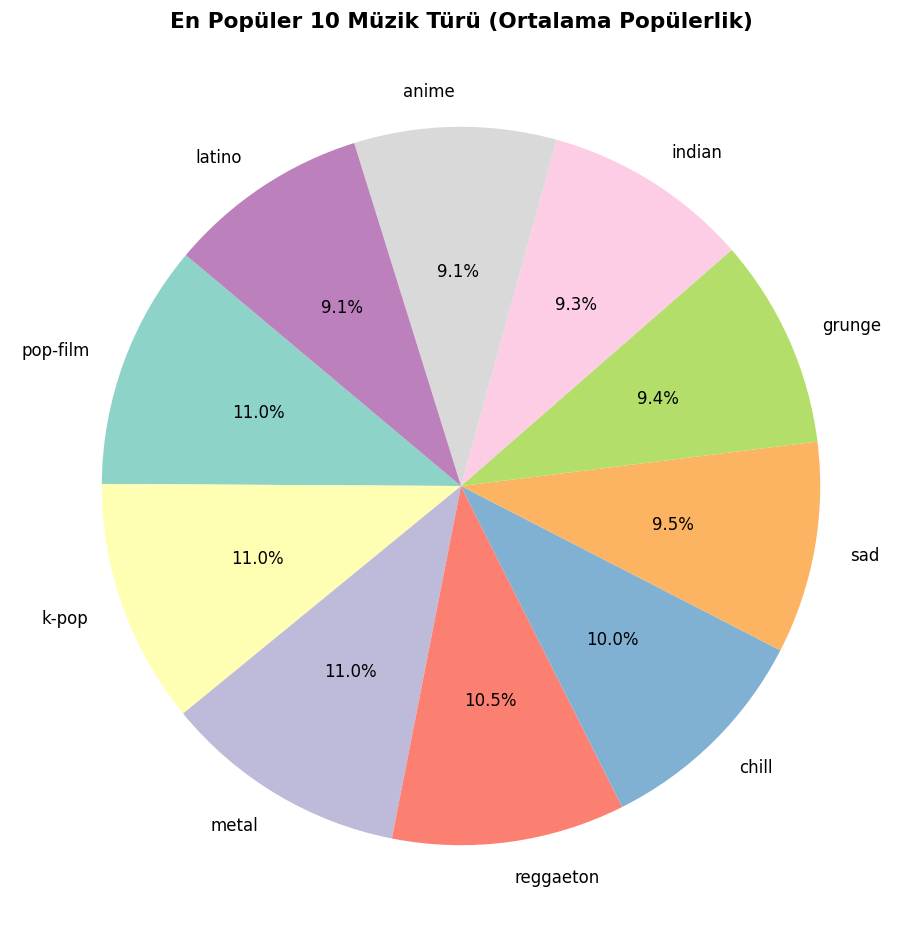

In [26]:
# En popüler 10 tür pie chart
top10 = df.groupBy("track_genre") \
          .agg(avg("popularity").alias("ort_populerlik")) \
          .orderBy(desc("ort_populerlik")) \
          .limit(10) \
          .toPandas()

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(top10['ort_populerlik'], labels=top10['track_genre'],
       autopct='%1.1f%%', startangle=140,
       colors=plt.cm.Set3.colors)
ax.set_title('En Popüler 10 Müzik Türü (Ortalama Popülerlik)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('top10_tur_pie.png', dpi=120)
plt.show()

**Çıkarım:** En yüksek ortalama popülerliğe sahip 10 tür incelendiğimizde reggaeton (%10.5) ile öne çıkmakta, bunu chill (%10.0) ve sad (%9.5) takip etmektedir. Türler arasındaki popülerlik farkının görece küçük olması popülerliğin yalnızca müzik türüne bağlı olmadığını, danceability, energy ve tempo gibi ses özelliklerinin de belirleyici rol oynayabilir

#### 4. Adım — Aykırı Değer (Outlier) Analizi